# Hybrid TPU + GDDR6-AiM Evaluation

This notebook evaluates an LLM workload on a hybrid architecture that combines a
TPU-style systolic array with a GDDR6-AiM (Accelerator-in-Memory) processing-in-memory
system. A `Fork` in the architecture lets the mapper assign each einsum to whichever
compute path is more efficient:

- **TPU path**: 128x128 systolic array with 128 MB global buffer (compute-bound ops)
- **AiM path**: 256 independent PUs with 32 GB/s per-bank DRAM (memory-bound ops)

## Setup

In [77]:
from pathlib import Path
from IPython.display import display
import accelforge as af
from accelforge.plotting.mappings import plot_energy_breakdown, plot_latency_breakdown
import matplotlib.pyplot as plt

examples_dir = Path("../examples")

AIM_ARCH = examples_dir / "arches" / "gddr6aim.yaml"
TPU_ARCH = examples_dir / "arches" / "tpu_v4i.yaml"
HYBRID_ARCH = examples_dir / "arches" / "tpu_aim_hybrid.yaml"
WORKLOAD = examples_dir / "workloads" / "gpt3_small_hybrid.yaml"

BATCH_SIZE = 1
N_TOKENS = 1  # Decode phase: 1 token at a time

aim_spec = af.Spec.from_yaml(
    AIM_ARCH,
    WORKLOAD,
    jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS},
)

tpu_spec = af.Spec.from_yaml(
    TPU_ARCH,
    WORKLOAD,
    jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS},
)

hybrid_spec = af.Spec.from_yaml(
    HYBRID_ARCH,
    WORKLOAD,
    jinja_parse_data={"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS},
)

## Architecture

The hybrid architecture uses a `Fork` to split into two compute paths from shared
HBM main memory. The TPU path has a deep memory hierarchy (GlobalBuffer, LocalBuffer,
Register) feeding a 128x128 systolic array. The AiM path has a 2 KB global buffer and 256 independent
processing units, each with its own 32 GB/s DRAM bank.

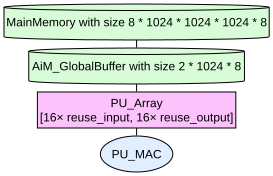

In [2]:
aim_spec.arch

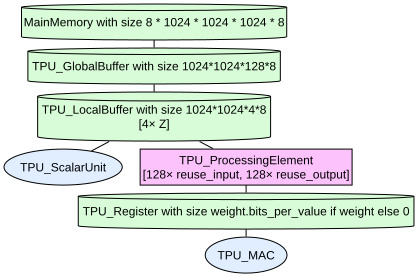

In [3]:
tpu_spec.arch

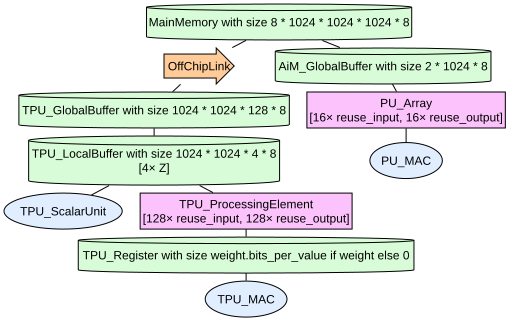

In [4]:
hybrid_spec.arch

## Workload

GPT-3-like transformer with small ranks for fast mapper evaluation. Includes QKV
projections, attention (QK, softmax, AV), output projection, and FFN layers.
Rank ratios match GPT-3 6.7B scaled down by 64x.

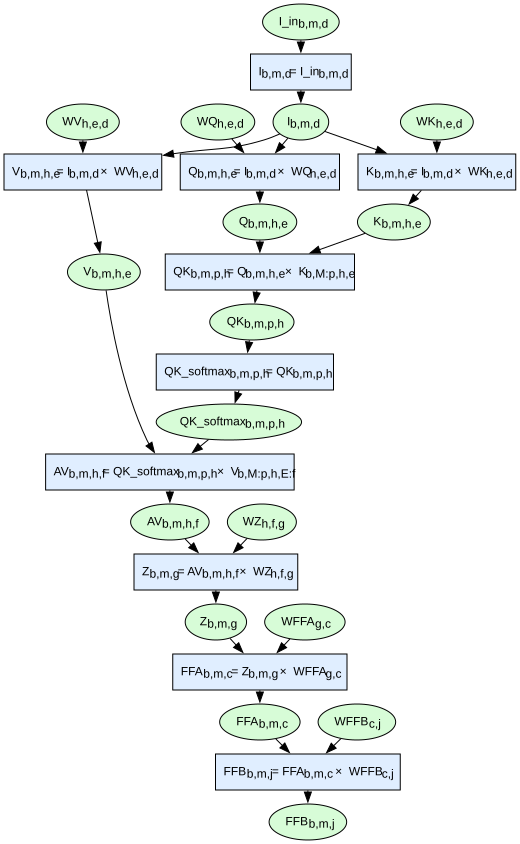

In [5]:
hybrid_spec.workload

## Map Workload to Architecture

We map the full workload in a single call. The mapper jointly optimizes across all
einsums and automatically assigns each to the TPU or AiM path through the Fork.

### AiM and TPU

In [49]:
aim_spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
aim_mapping = aim_spec.map_workload_to_arch()

tpu_spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
tpu_mapping = tpu_spec.map_workload_to_arch()

Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 10/10 [00:00<00:00, 58.40it/s]
Generating pmapping templates for compute PU_MAC Einsum I: 3it [00:00, 186.90it/s]
Generating pmapping templates for compute PU_MAC Einsum QK_softmax: 8it [00:00, 146.51it/s]
Generating pmapping templates for compute PU_MAC Einsum V: 24it [00:00, 143.34it/s]s]
Generating pmapping templates for compute PU_MAC Einsum K: 24it [00:00, 138.54it/s]
Generating pmapping templates for compute PU_MAC Einsum FFB: 12it [00:00, 165.50it/s]
Generating pmapping templates for compute PU_MAC Einsum Q: 24it [00:00, 134.49it/s]
Generating pmapping templates for compute PU_MAC Einsum Z: 24it [00:00, 142.15it/s]
Generating pmapping templates for compute PU_MAC Einsum FFA: 24it [00:00, 139.51it/s]
Generating pmapping templates for compute PU_MAC Einsum QK: 48it [00:00, 174.90it/s]
Generating pmapping templates for compute PU_MAC Einsum AV: 48it [00:00, 173.77it/s]
Generating jobs: 10

Einsum I has 3 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in AiM_GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	1	[I_in in MainMemory] T-b  T-d  T-m  [I_in in AiM_GlobalBuffer] [I in AiM_GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	2	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
Einsum V has 24 pmapping jobs:
	0	[WV in MainMemory] T-b  T-m  [I in AiM_GlobalBuffer] T-b  T-e  T-h  T-m  [V in AiM_GlobalBuffer] T-d  T-e  T-h  [WV in AiM_GlobalBuffer] T-b  T-m  S-reuse_output-m  S-reuse_output-h  S-reuse_output-e  S-reuse_output-d  S-reuse_output-b  S-reuse_input-h  S-reuse_input-e  PU_MAC computes V
	1	[WV in MainMemory] T-b  T-m  [I in AiM_GlobalBuffer] T-b  T-e  T-h  T-m  [WV in AiM_GlobalBuffer] T-b  T-m  [V in AiM_GlobalBuffer] T-b  T-d  T-e  T-h  T-m  S-reuse_output-m  S-reuse_outpu

Compressing pmappings: 100%|██████████| 10/10 [00:00<00:00, 43.92it/s]


Dirty joining with resource usage <= 1.2× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████| 173/173 [00:00<00:00, 669.85it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>latency=1.62e-07    Total<SEP>energy=5.62e-06
Final clean join.


Dirty pruning pmappings: 100%|██████████| 45/45 [00:00<00:00, 1205.56it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 55 -> 55 (100.00% kept) pmappings


Final consolidate: 100%|██████████| 2/2 [00:00<00:00, 150.70it/s]


Dirty joining mapping(s) valid & optimal! Returning...


### Hybrid

In [78]:
hybrid_spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
hybrid_mapping = hybrid_spec.map_workload_to_arch()

Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 10/10 [00:00<00:00, 34.92it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum I: 2it [00:00, 133.19it/s]
Generating pmapping templates for compute TPU_MAC Einsum I: 0it [00:00, ?it/s]t [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum K: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum V: 0it [00:00, ?it/s]
Generating pmapping templates for compute PU_MAC Einsum I: 3it [00:00, 166.28it/s]t/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Q: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum Z: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum QK: 0it [00:00, ?it/s]
Generating pmapping templates for compute TPU_ScalarUnit Einsum AV: 0it [00:00, ?it/s]]
Generating pmapping templates for compute TPU_ScalarUnit Einsum FFA: 0it [00:00, ?

Einsum I has 5 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I_in in OffChipLink] [I in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  [I in OffChipLink] [I_in in OffChipLink] S-Z-m  S-Z-d  S-Z-b  TPU_ScalarUnit computes I
	2	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	3	[I_in in MainMemory] T-b  T-d  T-m  [I in AiM_GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
	4	[I_in in MainMemory] T-b  T-d  T-m  [I_in in AiM_GlobalBuffer] [I in AiM_GlobalBuffer] T-b  T-d  T-m  S-reuse_output-m  S-reuse_output-d  S-reuse_output-b  PU_MAC computes I
Einsum V has 116 pmapping jobs:
	0	[WV in MainMemory] T-b  T-m  [WV in OffChipLink] [I in TPU_GlobalBuffer] T-b  T-e  T-h  T-m  [V in TPU_GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I in TPU_LocalBuffe

Compressing pmappings: 100%|██████████| 10/10 [00:00<00:00, 45.74it/s]


Dirty joining with resource usage <= 1.2× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████| 208/208 [00:00<00:00, 1397.40it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>latency=6.31e-06    Total<SEP>energy=5.62e-06
Final clean join.


Dirty pruning pmappings: 100%|██████████| 208/208 [00:00<00:00, 1481.08it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1920 -> 1920 (100.00% kept) pmappings


Final consolidate: 100%|██████████| 4/4 [00:00<00:00, 345.79it/s]


Dirty joining mapping(s) valid & optimal! Returning...


## Mapping Results

We pick a single mapping when the mapper returns a Pareto set (list of
optimal trade-offs). We select the mapping with the minimum EDP.

In [79]:
def print_energy_latency_breakdown(mapping):
    energy_by_comp = mapping.energy(per_component=True)
    latency_by_comp = mapping.latency(per_component=True)

    print("Energy Breakdown:")
    for component, energy in energy_by_comp.items():
        print(f"{component}: {energy}")

    print("\nLatency Breakdown:")
    for component, latency in latency_by_comp.items():
        print(f"{component}: {latency}")

def best_energy_latency_product(mapping):
    """Choose Pareto index minimizing energy * latency"""
    energies = mapping.energy()
    latencies = mapping.latency()

    if isinstance(energies, float):
        return mapping

    idx = min(range(len(energies)), key=lambda i: energies[i] * latencies[i])
    return mapping[idx]

BEST_AIM_MAPPING = best_energy_latency_product(aim_mapping)
BEST_TPU_MAPPING = best_energy_latency_product(tpu_mapping)
BEST_HYBRID_MAPPING = best_energy_latency_product(hybrid_mapping)

### AiM Mapping

In [ ]:
display(BEST_AIM_MAPPING.render())
print_energy_latency_breakdown(BEST_AIM_MAPPING)

### TPU Mapping

In [ ]:
display(BEST_TPU_MAPPING.render())
print_energy_latency_breakdown(BEST_TPU_MAPPING)

### Hybrid Mapping

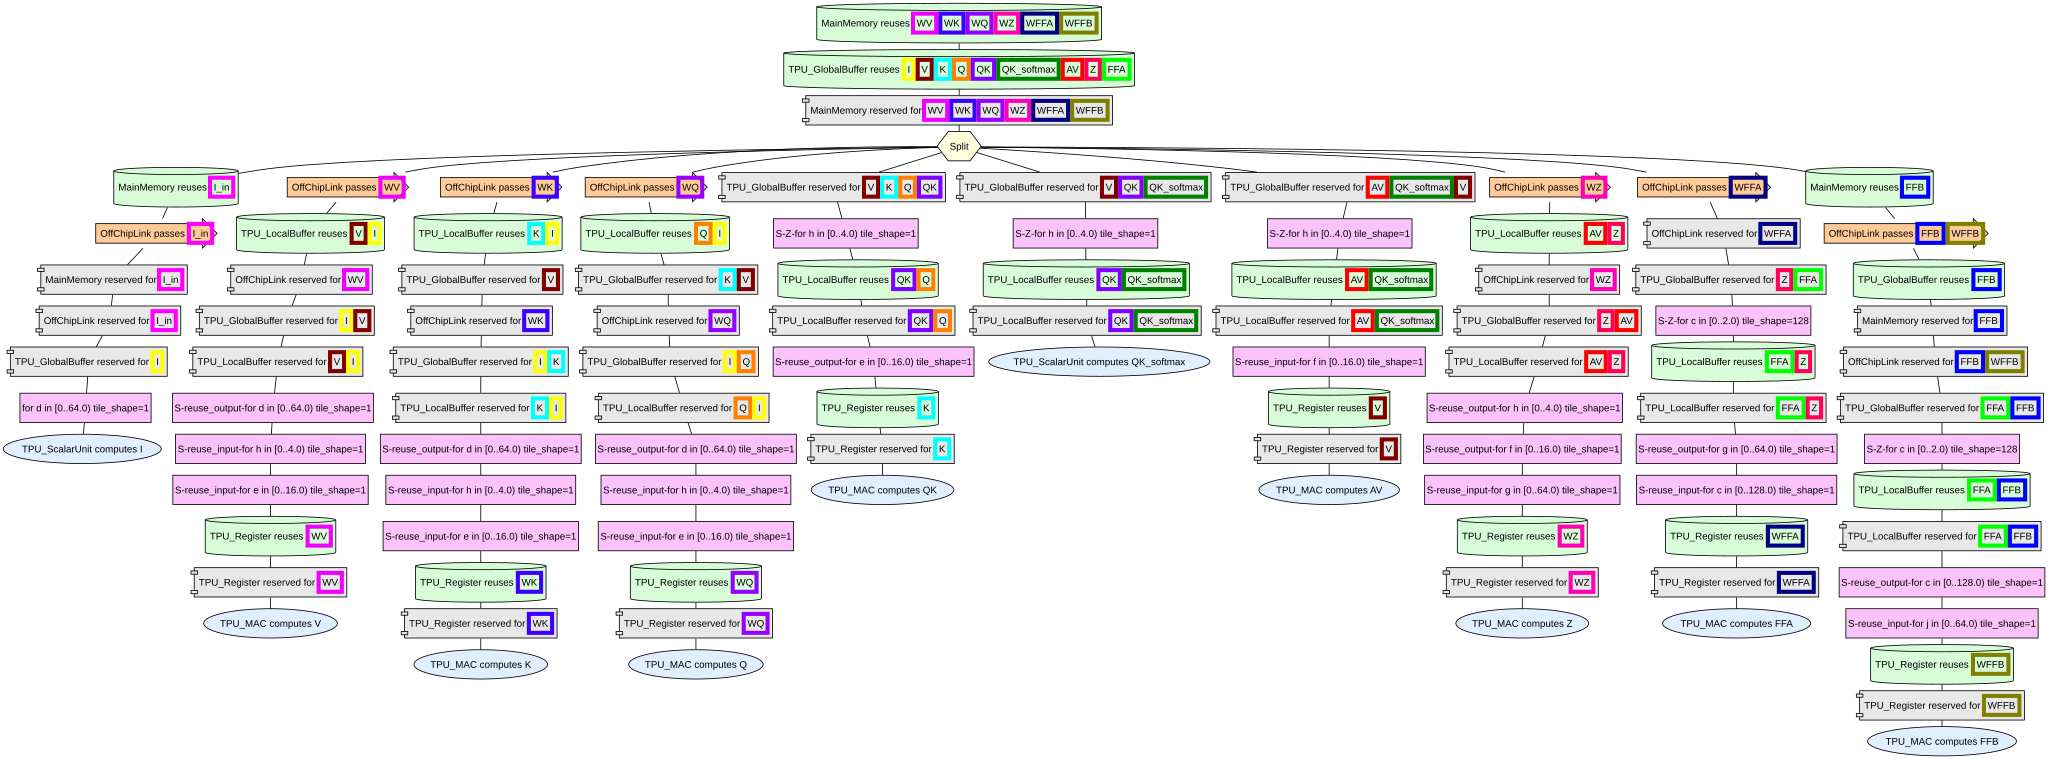

Energy Breakdown:
TPU_GlobalBuffer: 5.600256094973055e-08
OffChipLink: 0.0
MainMemory: 5.543014278686087e-06
TPU_LocalBuffer: 1.234892812255665e-08
TPU_ScalarUnit: 0.0
TPU_Register: 0.0
TPU_MAC: 4.13952e-09
AiM_GlobalBuffer: 0.0
PU_MAC: 0.0

Latency Breakdown:
TPU_GlobalBuffer: 1.6328125518327852e-09
OffChipLink: 6.30783961241832e-06
MainMemory: 1.6052116791342996e-07
TPU_ScalarUnit: 4.836309686062634e-10
TPU_MAC: 7.619047615037289e-09
TPU_LocalBuffer: 0
TPU_Register: 0


In [80]:
display(BEST_HYBRID_MAPPING.render())
print_energy_latency_breakdown(BEST_HYBRID_MAPPING)

### Einsum Allocations

Prints which einsums were allocated to the TPU or AiM in the hybrid architecture and mapping.

In [ ]:
# Determine which path each einsum uses by checking the mapping string
best_hybrid_mapping_energy = BEST_HYBRID_MAPPING.energy(per_einsum=True)
best_hybrid_mapping_latency = BEST_HYBRID_MAPPING.latency(per_einsum=True)

mapping_col = "Total<SEP>mapping"
tpu_einsums, aim_einsums = [], []

BEST_HYBRID_MAPPING.data["Total<SEP>mapping"]

for ein in best_hybrid_mapping_energy:
    mapping_str = str(BEST_HYBRID_MAPPING.data.get(mapping_col, ""))
    ein_col = f"{ein}<SEP>mapping"
    mapping_str = str(BEST_HYBRID_MAPPING.data[ein_col][0])
    print(mapping_str)
    if "TPU_MAC" in mapping_str or "TPU_ScalarUnit" in mapping_str:
        tpu_einsums.append(ein)
    elif "PU_MAC" in mapping_str:
        aim_einsums.append(ein)

print(f"\nTPU einsums: {', '.join(tpu_einsums) or 'none'}")
print(f"AiM einsums: {', '.join(aim_einsums) or 'none'}")

nodes=[Storage(tensors=['I_in'], component='MainMemory', component_object=Memory(name='MainMemory', spatial=[], component_class=None, component_model=None, component_modeling_log=['Calculating energy for MainMemory action read.', 'Setting MainMemory energy to action.energy=7.03e-12', 'Calculating energy for MainMemory action write.', 'Setting MainMemory energy to action.energy=7.03e-12', 'Calculating latency for MainMemory action read.', 'Setting MainMemory latency to action.latency=2.0358306188925081e-13', 'Calculating latency for MainMemory action write.', 'Setting MainMemory latency to action.latency=2.0358306188925081e-13', 'Using predefined leak power value self.leak_power=0', 'Calculating energy for MainMemory action read.', 'Setting MainMemory energy to action.energy=7.03e-12', 'Calculating energy for MainMemory action write.', 'Setting MainMemory energy to action.energy=7.03e-12', 'Calculating latency for MainMemory action read.', 'Setting MainMemory latency to action.latency=2

## Per-Component Energy

Energy breakdown by component, stacked by einsum and tensors.

### Einsum

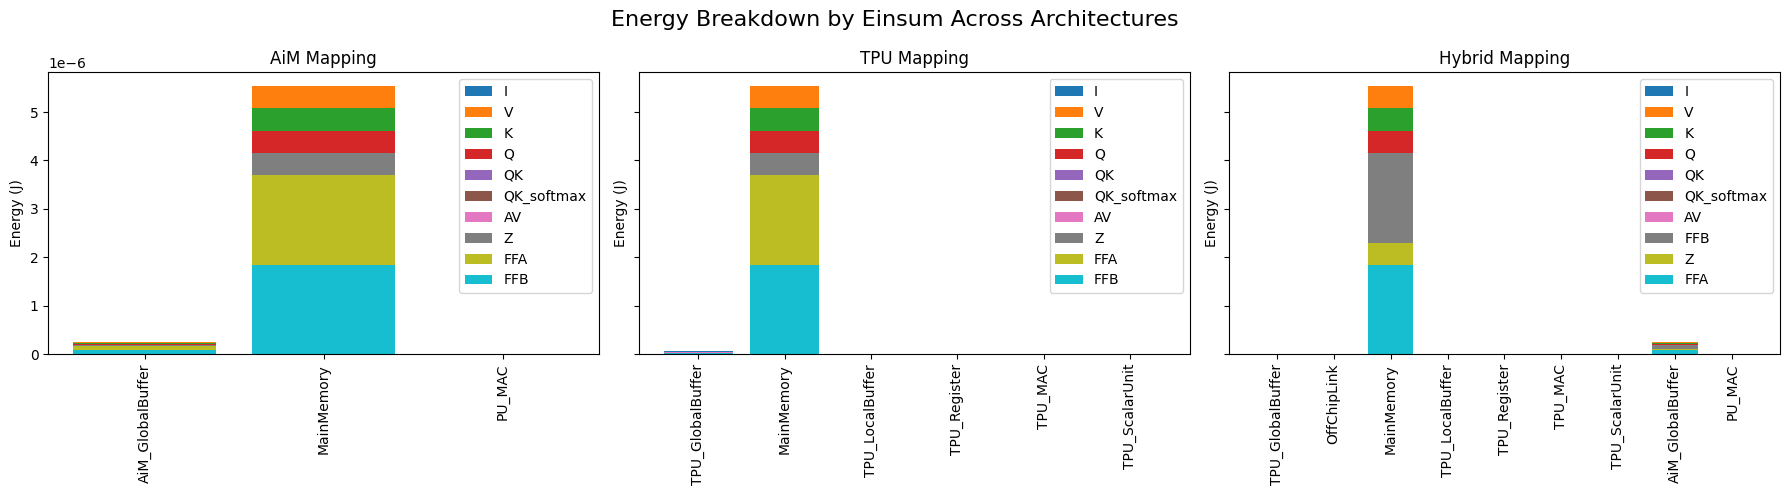

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

plot_energy_breakdown(
    [BEST_AIM_MAPPING],
    separate_by=["component"],
    stack_by=["einsum"],
    ax=axs[0],
)
axs[0].set_title("AiM Mapping")

plot_energy_breakdown(
    [BEST_TPU_MAPPING],
    separate_by=["component"],
    stack_by=["einsum"],
    ax=axs[1],
)
axs[1].set_title("TPU Mapping")

plot_energy_breakdown(
    [BEST_HYBRID_MAPPING],
    separate_by=["component"],
    stack_by=["einsum"],
    ax=axs[2],
)
axs[2].set_title("Hybrid Mapping")

fig.suptitle("Energy Breakdown by Einsum Across Architectures", fontsize=16)
plt.tight_layout()

### Tensor

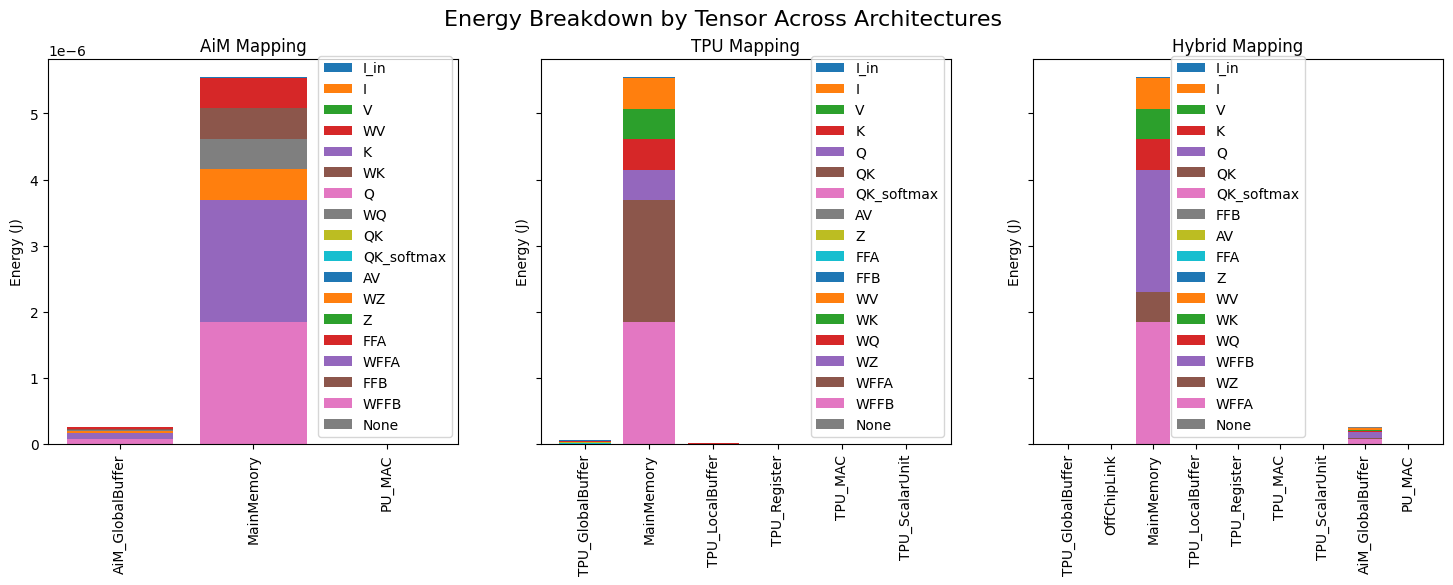

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

plot_energy_breakdown(
    [BEST_AIM_MAPPING],
    separate_by=["component"],
    stack_by=["tensor"],
    ax=axs[0],
)
axs[0].set_title("AiM Mapping")

plot_energy_breakdown(
    [BEST_TPU_MAPPING],
    separate_by=["component"],
    stack_by=["tensor"],
    ax=axs[1],
)
axs[1].set_title("TPU Mapping")

plot_energy_breakdown(
    [BEST_HYBRID_MAPPING],
    separate_by=["component"],
    stack_by=["tensor"],
    ax=axs[2],
)
axs[2].set_title("Hybrid Mapping")

fig.suptitle("Energy Breakdown by Tensor Across Architectures", fontsize=16)
plt.show()

## Per-component Latency

Latency breakdown by component, stacked by einsum.

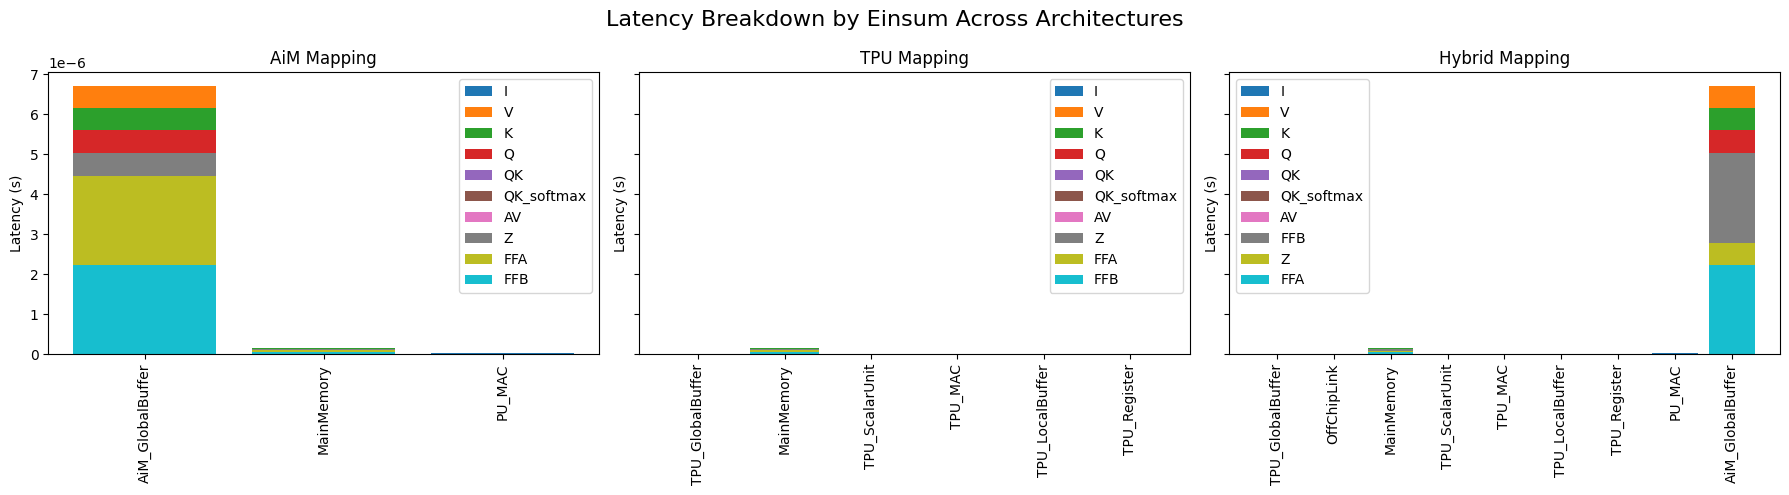

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

plot_latency_breakdown(
    [BEST_AIM_MAPPING],
    separate_by=["component"],
    stack_by=["einsum"],
    ax=axs[0],
)
axs[0].set_title("AiM Mapping")

plot_latency_breakdown(
    [BEST_TPU_MAPPING],
    separate_by=["component"],
    stack_by=["einsum"],
    ax=axs[1],
)
axs[1].set_title("TPU Mapping")

plot_latency_breakdown(
    [BEST_HYBRID_MAPPING],
    separate_by=["component"],
    stack_by=["einsum"],
    ax=axs[2],
)
axs[2].set_title("Hybrid Mapping")

fig.suptitle("Latency Breakdown by Einsum Across Architectures", fontsize=16)
plt.tight_layout()

## Decode vs Prefill Comparison

During decode (M=1), operations are memory-bound and should favor AiM.
During prefill (M=128), operations become compute-bound and should favor the TPU.
We compare the two phases by re-mapping with different token counts.

In [ ]:
# results_by_phase = {}

# for phase, tokens in [("Decode (M=1)", 1), ("Prefill (M=128)", 128)]:
#     phase_params = {"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": tokens}
#     phase_spec = af.Spec.from_yaml(
#         HYBRID_ARCH, WORKLOAD, jinja_parse_data=phase_params
#     )
#     phase_spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
#     phase_mapping = phase_spec.map_workload_to_arch()
#     for i in range(len(phase_mapping)):
#         display(phase_mapping[i].render())
#     phase_idx = best_energy_latency_product_idx(phase_mapping)
#     selected_phase_idx = 0 if phase_idx is None else phase_idx
#     results_by_phase[phase] = {
#         "mapping": phase_mapping,
#         "selected_idx": selected_phase_idx,
#         "energy": pick(phase_mapping.energy(), selected_phase_idx),
#         "latency": pick(phase_mapping.latency(), selected_phase_idx),
#     }
#     print(
#         f"{phase}: idx={selected_phase_idx}, "
#         f"energy={results_by_phase[phase]['energy']:.4e} J, "
#         f"latency={results_by_phase[phase]['latency']:.4e} s"
#     )

In [ ]:
# phase_mappings = [v["mapping"] for v in results_by_phase.values()]
# phase_labels = list(results_by_phase.keys())

# plot_energy_breakdown(
#     phase_mappings,
#     separate_by=["component"],
#     stack_by=["einsum"],
#     labels=phase_labels,
# )

## Per-Einsum: TPU vs AiM  Comparison

To understand why the mapper picks one path over the other, we map each einsum
independently to a TPU-only architecture and an AiM-only architecture (both sharing
the same MainMemory). This lets us directly compare energy and latency per-einsum
on each path.

In [ ]:
# params = {"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS}
# einsum_names = [e.name for e in spec.workload.einsums]

# comparison = {}

# for name in einsum_names:
#     row = {}
#     for label, arch_path in [("TPU",'/Users/erik/Downloads/accelforge/examples/arches/tpu_only.yaml' ), ("AiM", '/Users/erik/Downloads/accelforge/examples/arches/aim_only.yaml')]:
#         try:
#             s = af.Spec.from_yaml(arch_path, str(WORKLOAD), jinja_parse_data=params)
#             s.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
#             r = s.map_workload_to_arch(einsum_names=[name], print_progress=False)
#             # Pick min-latency Pareto point
#             lat = r.latency()
#             if isinstance(lat, list):
#                 idx = min(range(len(lat)), key=lambda i: lat[i])
#                 row[label] = {"energy": lat[idx], "latency": lat[idx]}
#                 # Fix: get energy at same index
#                 eng = r.energy()
#                 row[label] = {"energy": eng[idx], "latency": lat[idx]}
#             else:
#                 row[label] = {"energy": r.energy(), "latency": r.latency()}
#         except Exception as e:
#             row[label] = {"energy": float("nan"), "latency": float("nan"), "error": str(e)}
#     comparison[name] = row

#     tpu_lat = row["TPU"]["latency"]
#     aim_lat = row["AiM"]["latency"]
#     winner = "TPU" if tpu_lat <= aim_lat else "AiM"
#     print(f"{name:<15} TPU lat={tpu_lat:.3e}  AiM lat={aim_lat:.3e}  -> {winner}")

### Summary Table

In [ ]:
# import math

# header = f"{'Einsum':<15} {'TPU Energy':>12} {'TPU Latency':>12} {'AiM Energy':>12} {'AiM Latency':>12} {'Lat Winner':>10} {'Lat Ratio':>10}"
# print(header)
# print("-" * len(header))

# for name, row in comparison.items():
#     te = row["TPU"]["energy"]
#     tl = row["TPU"]["latency"]
#     ae = row["AiM"]["energy"]
#     al = row["AiM"]["latency"]

#     if math.isnan(tl) or math.isnan(al):
#         winner = "error"
#         ratio = "N/A"
#     elif tl <= al:
#         winner = "TPU"
#         ratio = f"{al/tl:.2f}x"
#     else:
#         winner = "AiM"
#         ratio = f"{tl/al:.2f}x"

#     print(f"{name:<15} {te:>12.3e} {tl:>12.3e} {ae:>12.3e} {al:>12.3e} {winner:>10} {ratio:>10}")

### Latency and Energy Comparison Charts

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# names = list(comparison.keys())
# tpu_latencies = [comparison[n]["TPU"]["latency"] for n in names]
# aim_latencies = [comparison[n]["AiM"]["latency"] for n in names]
# tpu_energies = [comparison[n]["TPU"]["energy"] for n in names]
# aim_energies = [comparison[n]["AiM"]["energy"] for n in names]

# x = np.arange(len(names))
# width = 0.35

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# # Latency comparison
# ax1.bar(x - width/2, tpu_latencies, width, label="TPU", color="steelblue")
# ax1.bar(x + width/2, aim_latencies, width, label="AiM", color="coral")
# ax1.set_ylabel("Latency (s)")
# ax1.set_title("Per-Einsum Latency: TPU vs AiM")
# ax1.set_xticks(x)
# ax1.set_xticklabels(names, rotation=45, ha="right")
# ax1.legend()
# ax1.set_yscale("log")

# # Energy comparison
# ax2.bar(x - width/2, tpu_energies, width, label="TPU", color="steelblue")
# ax2.bar(x + width/2, aim_energies, width, label="AiM", color="coral")
# ax2.set_ylabel("Energy (J)")
# ax2.set_title("Per-Einsum Energy: TPU vs AiM")
# ax2.set_xticks(x)
# ax2.set_xticklabels(names, rotation=45, ha="right")
# ax2.legend()
# ax2.set_yscale("log")

# plt.tight_layout()
# plt.show()